In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
import pandas as pd

In [3]:
def rho(m):
    green = ((1.5 * m) / (17 * 0.3))
    amber = ((1.0 * m) / (0.7 * 17))
    red = ((0.5 * m) / (0.4 * 17))
    return green + amber + red

In [4]:
ms = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.5, 3.0]

In [5]:
data = {m: pd.read_csv(f"m{str(int(m * 100)).zfill(3)}/results/evaluation.csv") for m in ms}

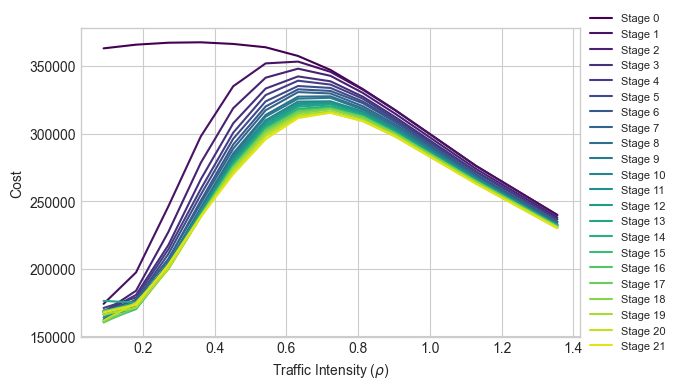

In [6]:
fig, ax = plt.subplots(1, figsize=(6, 4))
cmap = mpl.colormaps["viridis"]
for s in range(22):
    ax.plot([rho(m) for m in ms], [data[m].mean()[f'Stage {s}'] for m in ms], label=f"Stage {s}", c=cmap(s/22))
ax.set_xlabel(r"Traffic Intensity ($\rho$)")
ax.set_ylabel("Cost")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
plt.tight_layout()
fig.savefig("vary_arrivals.pdf", bbox_inches='tight')

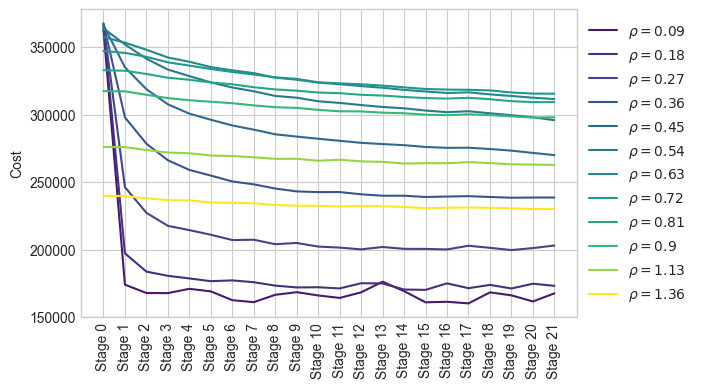

In [7]:
fig, ax = plt.subplots(1, figsize=(8, 4))
cmap = mpl.colormaps["viridis"]
for i, m in enumerate(ms):
    ax.plot(range(22), [data[m].mean()[f"Stage {s}"] for s in range(22)], c=cmap(rho(m) / rho(3.0)), label=fr"$\rho = {round(rho(m), 2)}$")
ax.set_xticks(range(22))
ax.set_xticklabels([f"Stage {s}" for s in range(22)], rotation=90)
ax.set_ylabel("Cost")
box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()